In [20]:
import pandas as pd 
import numpy as np 
import requests
from bs4 import BeautifulSoup
import time
import random
import requests
# import cloudscraper 
# import re 

In [21]:
headers={'User-Agent':'Mozilla/5.0 (Windows NT 6.3; Win 64 ; x64) Apple WeKit /537.36(KHTML , like Gecko) Chrome/80.0.3987.162 Safari/537.36'} 
webpage = requests.get('https://www.ambitionbox.com/list-of-companies?page=1',headers=headers).text

# **traversing over 100 pages of the website and storing it in a list of webpages**

In [24]:
webpageList = []
for i in range(1,501):
    temp = requests.get(f'https://www.ambitionbox.com/list-of-companies?page={i}',headers=headers).text
    soup = BeautifulSoup(temp, 'html.parser')
    webpageList.append(soup)

In [4]:
# webpageList[0].find_all('a',class_="item router-link-active")

# `Fetching and storing the data for every page in a list format to make pandas dataset`

In [35]:
rows = []

for pages in webpageList:
    for i in pages.find_all('div', class_='companyCardWrapper'):

        # --- Company Name ---
        name_tag = i.find('h2', class_='companyCardWrapper__companyName')
        company = name_tag.text.strip() if name_tag else np.nan

        # --- Domain / City ---
        domain_tag = i.find('span', class_='companyCardWrapper__interLinking')
        domain = domain_tag.text.strip() if domain_tag else np.nan

        # --- review ---
        review_tag = i.find('div',style='height:auto;')
        review = float(review_tag.text.strip()) if review_tag else np.nan

        # --- Salary_Count ---
        salary_tag = i.find_all('span',class_="companyCardWrapper__ActionCount")
        salary = salary_tag[1].text.strip() if len(salary_tag)>1 else np.nan

        # --- Highly & Critically Rated ---
        # --- Highly & Critically Rated ---
        rating_values = i.find_all('span', class_=lambda x: x and 'ratingValues' in x)

        highly_rate_cause = np.nan
        critically_rate_cause = np.nan

        if len(rating_values) == 1:
            # We don't know if it's highly or critical
            # So check previous sibling text
            parent_text = rating_values[0].parent.get_text()
            
            if "Highly" in parent_text:
                highly_rate_cause = rating_values[0].text.strip()
            else:
                critically_rate_cause = rating_values[0].text.strip()

        elif len(rating_values) >= 2:
            highly_rate_cause = rating_values[0].text.strip()
            critically_rate_cause = rating_values[1].text.strip()
        
        # --- job  openings ---
        job_opening_tags = i.find_all('span',class_="companyCardWrapper__ActionCount")
        job_opening = job_opening_tags[3].text.strip() if len(job_opening_tags)>3 else np.nan 

        rows.append([
            company, domain , review , salary,
                    highly_rate_cause , critically_rate_cause , job_opening
        ])

### **dataset making**

In [36]:
frame = pd.DataFrame(rows,columns=["Company","Domain","Reviews","Emp_sal_count","pos_rating","neg_rating","vacancies"])

In [37]:
frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        10000 non-null  str    
 1   Domain         10000 non-null  str    
 2   Reviews        9992 non-null   float64
 3   Emp_sal_count  10000 non-null  str    
 4   pos_rating     5777 non-null   str    
 5   neg_rating     7771 non-null   str    
 6   vacancies      10000 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.0 KB


In [38]:
frame

,Company,Domain,Reviews,Emp_sal_count,pos_rating,neg_rating,vacancies
0,TCS,IT Services & Consulting | Bengaluru +448 othe...,3.3,10.3L,Job Security,"Promotions, Salary, Work Satisfaction",4.5k
1,Accenture,IT Services & Consulting | Bengaluru +261 othe...,3.7,7.1L,NaN,"Promotions, Salary, Work Satisfaction",23.3k
2,Wipro,IT Services & Consulting | Hyderabad +375 othe...,3.6,4.9L,NaN,"Promotions, Salary, Work Satisfaction",4.1k
3,Cognizant,IT Services & Consulting | Hyderabad +233 othe...,3.7,6.1L,NaN,"Promotions, Salary, Work Satisfaction",869
4,Capgemini,IT Services & Consulting | Bengaluru +187 othe...,3.6,4.9L,"Work Life Balance, Job Security","Promotions, Salary, Work Satisfaction",2.1k
...,...,...,...,...,...,...,...
9995,Euclid Innovations,IT Services & Consulting | Hyderabad +5 other ...,3.0,744,NaN,"Job Security, Skill Development, Promotions",13
9996,G Plast,Industrial Machinery | Coimbatore +2 other loc...,3.3,551,NaN,"Promotions, Company Culture, Work Satisfaction",12
9997,Feat Systems,Financial Services | Mumbai +6 other locations,3.3,331,NaN,"Salary, Promotions, Work Satisfaction",--
9998,Srei Infrastructure Finance,Financial Services | Kolkata +32 other locations,4.0,379,"Work Life Balance, Work Satisfaction, Salary",Promotions,--


In [9]:
print("Highly Rated For" in pages.text)

True


In [40]:
def domain_differentiator(col):
    return col.split("|")[0]
def location_differentiator(col):
    if len(col.split("|"))>1:
        return col.split("|")[1]
    return np.nan 

frame['domain'] = frame['Domain'].apply(domain_differentiator)
frame['Locations'] = frame['Domain'].apply(location_differentiator)

In [41]:
frame = frame.drop(['Domain'],axis=1)
frame.head()

,Company,Reviews,Emp_sal_count,pos_rating,neg_rating,vacancies,domain,Locations
0,TCS,3.3,10.3L,Job Security,"Promotions, Salary, Work Satisfaction",4.5k,IT Services & Consulting,Bengaluru +448 other locations
1,Accenture,3.7,7.1L,NaN,"Promotions, Salary, Work Satisfaction",23.3k,IT Services & Consulting,Bengaluru +261 other locations
2,Wipro,3.6,4.9L,NaN,"Promotions, Salary, Work Satisfaction",4.1k,IT Services & Consulting,Hyderabad +375 other locations
3,Cognizant,3.7,6.1L,NaN,"Promotions, Salary, Work Satisfaction",869,IT Services & Consulting,Hyderabad +233 other locations
4,Capgemini,3.6,4.9L,"Work Life Balance, Job Security","Promotions, Salary, Work Satisfaction",2.1k,IT Services & Consulting,Bengaluru +187 other locations


In [30]:
frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        10000 non-null  str    
 1   Reviews        0 non-null      float64
 2   Emp_sal_count  10000 non-null  str    
 3   pos_rating     5777 non-null   str    
 4   neg_rating     7771 non-null   str    
 5   vacancies      10000 non-null  str    
 6   domain         10000 non-null  str    
 7   Locations      9713 non-null   str    
dtypes: float64(1), str(7)
memory usage: 625.1 KB


In [42]:
def vacancy_setter(vac):
    if vac[-1]=='k':
        return float(vac[:-1])*1000
    try:
        isinstance(float(vac),float)
    except:
        return np.nan 
    return float(vac)

In [43]:
frame['vacancies'] = frame['vacancies'].apply(vacancy_setter)
frame.head()

,Company,Reviews,Emp_sal_count,pos_rating,neg_rating,vacancies,domain,Locations
0,TCS,3.3,10.3L,Job Security,"Promotions, Salary, Work Satisfaction",4500.0,IT Services & Consulting,Bengaluru +448 other locations
1,Accenture,3.7,7.1L,NaN,"Promotions, Salary, Work Satisfaction",23300.0,IT Services & Consulting,Bengaluru +261 other locations
2,Wipro,3.6,4.9L,NaN,"Promotions, Salary, Work Satisfaction",4100.0,IT Services & Consulting,Hyderabad +375 other locations
3,Cognizant,3.7,6.1L,NaN,"Promotions, Salary, Work Satisfaction",869.0,IT Services & Consulting,Hyderabad +233 other locations
4,Capgemini,3.6,4.9L,"Work Life Balance, Job Security","Promotions, Salary, Work Satisfaction",2100.0,IT Services & Consulting,Bengaluru +187 other locations


# **labeling the company in review groups - A,B,C,D**

In [44]:
frame['Reviews_grp'] = pd.cut(frame['Reviews'],bins=[1,2,3,4,5],labels=['D','C','B','A'])
frame.head()

,Company,Reviews,Emp_sal_count,pos_rating,neg_rating,vacancies,domain,Locations,Reviews_grp
0,TCS,3.3,10.3L,Job Security,"Promotions, Salary, Work Satisfaction",4500.0,IT Services & Consulting,Bengaluru +448 other locations,B
1,Accenture,3.7,7.1L,NaN,"Promotions, Salary, Work Satisfaction",23300.0,IT Services & Consulting,Bengaluru +261 other locations,B
2,Wipro,3.6,4.9L,NaN,"Promotions, Salary, Work Satisfaction",4100.0,IT Services & Consulting,Hyderabad +375 other locations,B
3,Cognizant,3.7,6.1L,NaN,"Promotions, Salary, Work Satisfaction",869.0,IT Services & Consulting,Hyderabad +233 other locations,B
4,Capgemini,3.6,4.9L,"Work Life Balance, Job Security","Promotions, Salary, Work Satisfaction",2100.0,IT Services & Consulting,Bengaluru +187 other locations,B


<Axes: xlabel='category', ylabel='no. of companies'>

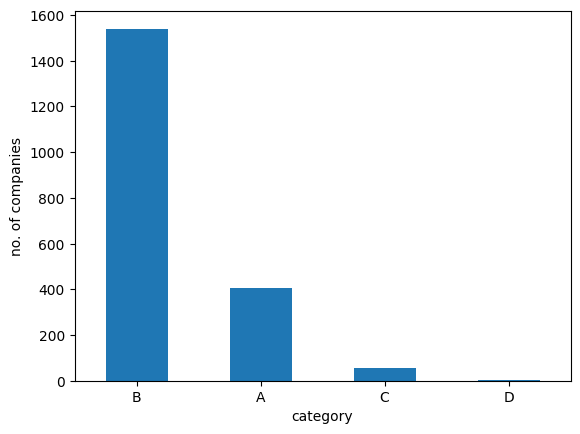

In [16]:
frame['Reviews_grp'].value_counts().plot(
    kind='bar',xlabel='category',ylabel='no. of companies',rot=0
)

In [17]:
frame['Locations'].unique()

array([' Bengaluru +439 other locations',
       ' Bengaluru +255 other locations',
       ' Hyderabad +370 other locations', ...,
       ' Gurugram +115 other locations', ' Patna +63 other locations',
       ' Mumbai +67 other locations'], shape=(1289,), dtype=object)

In [ ]:
import re

text = "Bengaluru +439 other locations"

# The Pattern:
# ([a-zA-Z]+)  -> Group 1: The City (letters)
# \s+\+        -> Space and the plus sign
# (\d+)        -> Group 2: The Number (digits)
pattern = r"([a-zA-Z]+)\s+\+(\d+)"

match = re.search(pattern, text)

if match:
    city = match.group(1)    # Extracts 'Bengaluru'
    count = match.group(2)   # Extracts '439'
    
    print(f"City: {city}")
    print(f"Number of locations: {count}")

# **differentiating the main and the total locations**

In [39]:
def main_location(loc):
    if isinstance(loc,float):
        return np.nan 
    pattern = r"([a-zA-Z]+)\s+\+(\d+)"
    match = re.search(pattern, loc)
    if match:
        main_loc =  match.group(1)
        return main_loc
    return np.nan

def oth_location(loc):
    if isinstance(loc,float):
        return np.nan
    pattern = r"([a-zA-Z]+)\s+\+(\d+)"
    match = re.search(pattern, loc)
    if match:
        oth_locs = match.group(2)
        return oth_locs
    return np.nan

print(main_location("hyderabad +78 locations"))
print(oth_location("hyderabad +78 locations"))
# oth_location(text)
main_locations = frame['Locations'].apply(main_location)
oth_locations = frame['Locations'].apply(oth_location)
oth_locations

hyderabad
78


0       439
1       255
2       370
3       231
4       182
       ... 
1995     66
1996     63
1997     31
1998     67
1999      8
Name: Locations, Length: 2000, dtype: object

In [43]:
frame['main_loc'] = main_locations
frame['total_locations'] = oth_locations
frame = frame.drop(['Locations'],axis=1)
frame.head()

,Company,Reviews,Emp_sal_count,pos_rating,neg_rating,vacancies,domain,Reviews_grp,main_loc,total_locations
0,TCS,3.3,9.9L,Job Security,"Promotions / Appraisal, Salary & Benefits, Wor...",3000.0,IT Services & Consulting,B,Bengaluru,439
1,Accenture,3.7,6.5L,NaN,"Promotions / Appraisal, Salary & Benefits, Wor...",38400.0,IT Services & Consulting,B,Bengaluru,255
2,Wipro,3.6,4.8L,NaN,"Promotions / Appraisal, Salary & Benefits, Wor...",5000.0,IT Services & Consulting,B,Hyderabad,370
3,Cognizant,3.6,6L,NaN,"Promotions / Appraisal, Salary & Benefits, Wor...",601.0,IT Services & Consulting,B,Hyderabad,231
4,Capgemini,3.7,4.8L,"Work Life Balance, Job Security","Promotions / Appraisal, Salary & Benefits, Wor...",2300.0,IT Services & Consulting,B,Bengaluru,182


# **TOP 10 Domains**

<Axes: title={'center': 'Top 10 domains in Ambitionbox'}, xlabel='domain'>

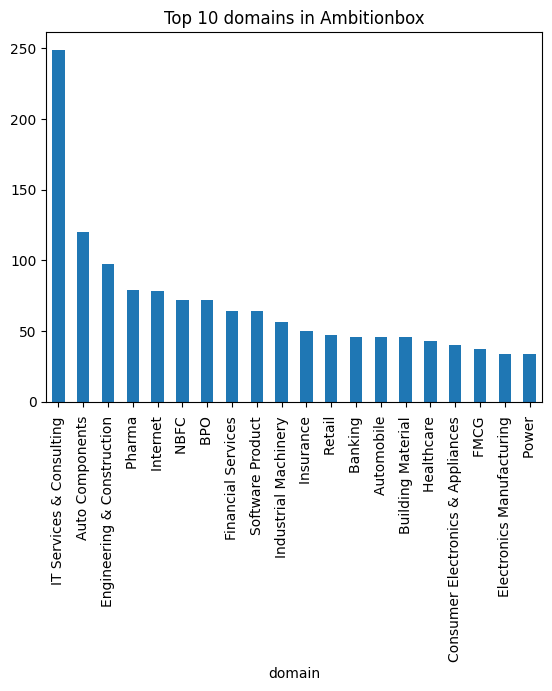

In [51]:
frame['domain'].value_counts().head(20).plot(
    kind='bar' , title='Top 10 domains in Ambitionbox',fontsize=10
)

C:\Users\gssha\AppData\Local\Temp\ipykernel_11580\172019756.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frame.groupby('Reviews_grp')['Reviews_grp'].count().plot(


<Axes: ylabel='Reviews_grp'>

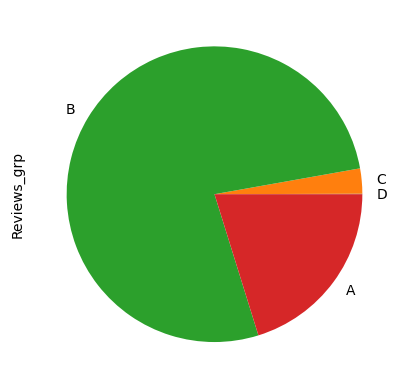

In [56]:
import matplotlib.pyplot as plt 
frame.groupby('Reviews_grp')['Reviews_grp'].count().plot(
    kind='pie'
)